# Eksperimen SML - Farrel Ghozy Affifudin

## 1. Perkenalan Dataset

**Dataset**: Pima Indians Diabetes Database

**Sumber**: Kaggle / UCI Machine Learning Repository

Dataset ini berasal dari National Institute of Diabetes and Digestive and Kidney Diseases. Tujuan dari dataset ini adalah untuk memprediksi secara diagnostis apakah seorang pasien menderita diabetes atau tidak, berdasarkan pengukuran diagnostik tertentu yang terdapat dalam dataset. Beberapa batasan yang perlu diperhatikan adalah, seluruh pasien yang tercatat dalam dataset ini adalah wanita berusia minimal 21 tahun keturunan Indian Pima.

### Informasi Fitur:
| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| Pregnancies | Numerik | Jumlah kehamilan |
| Glucose | Numerik | Konsentrasi glukosa plasma (mg/dL) |
| BloodPressure | Numerik | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Numerik | Ketebalan lipatan kulit trisep (mm) |
| Insulin | Numerik | Insulin serum 2 jam (mu U/mL) |
| BMI | Numerik | Indeks massa tubuh (kg/m²) |
| DiabetesPedigreeFunction | Numerik | Fungsi silsilah diabetes |
| Age | Numerik | Usia (tahun) |
| Outcome | Kategorikal | Hasil diagnosis (0 = Non-Diabetic, 1 = Diabetic) |

**Tujuan**: Membangun model klasifikasi untuk memprediksi kemungkinan seseorang menderita diabetes berdasarkan fitur-fitur medis yang tersedia.

## 2. Import Library

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print("[INFO] Semua library berhasil diimpor.")

[INFO] Semua library berhasil diimpor.


## 3. Memuat Dataset

Pada tahap ini, dataset dimuat ke dalam notebook menggunakan pandas. Dataset yang digunakan adalah Pima Indians Diabetes dalam format CSV.

In [2]:
df = pd.read_csv('../diabetes_raw/diabetes_with_headers.csv')
print(f"[INFO] Dataset berhasil dimuat.")
print(f"[INFO] Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"[INFO] Nama kolom: {list(df.columns)}")
print()
df.head(10)

[INFO] Dataset berhasil dimuat.
[INFO] Shape: 768 baris, 9 kolom
[INFO] Nama kolom: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 4. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik dataset, mendeteksi anomali, dan menentukan langkah preprocessing yang tepat.

In [3]:
os.makedirs('preprocessing/diabetes_preprocessing', exist_ok=True)
print('[INFO] Direktori output siap.')

[INFO] Direktori output siap.


### 4.1 Informasi Dataset

In [4]:
print("=== Info Dataset ===")
print(df.info())
print(f"\nDuplicated rows: {df.duplicated().sum()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Duplicated rows: 0

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                        

### 4.2 Statistik Deskriptif

In [5]:
print("=== Statistik Deskriptif ===")
df.describe().T

=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 4.3 Distribusi Target

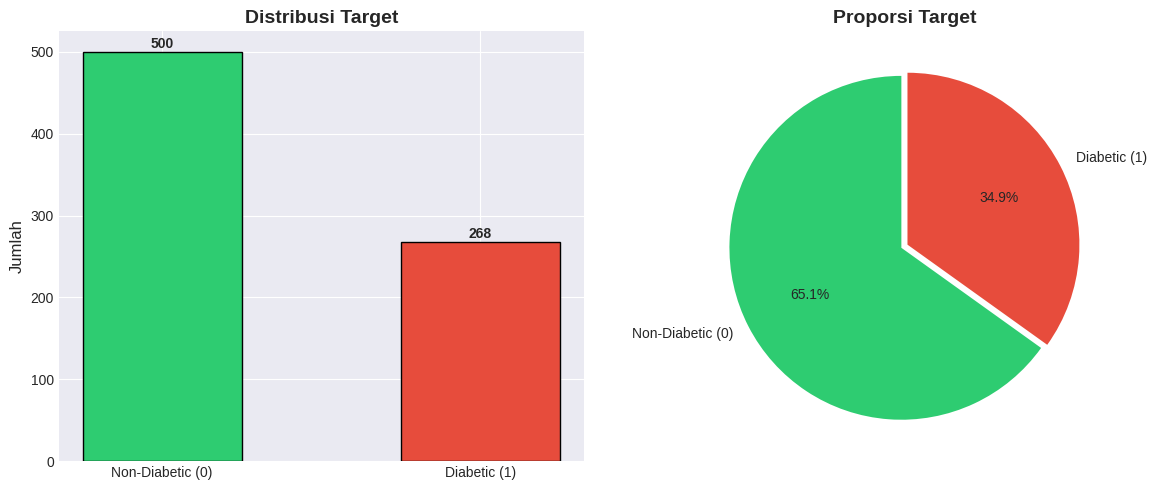

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
target_counts = df['Outcome'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels = ['Non-Diabetic (0)', 'Diabetic (1)']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Proporsi Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing/diabetes_preprocessing/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.4 Deteksi Nilai Nol yang Tidak Valid

        Fitur  Jumlah Nol  Persentase
      Glucose           5        0.65
BloodPressure          35        4.56
SkinThickness         227       29.56
      Insulin         374       48.70
          BMI          11        1.43


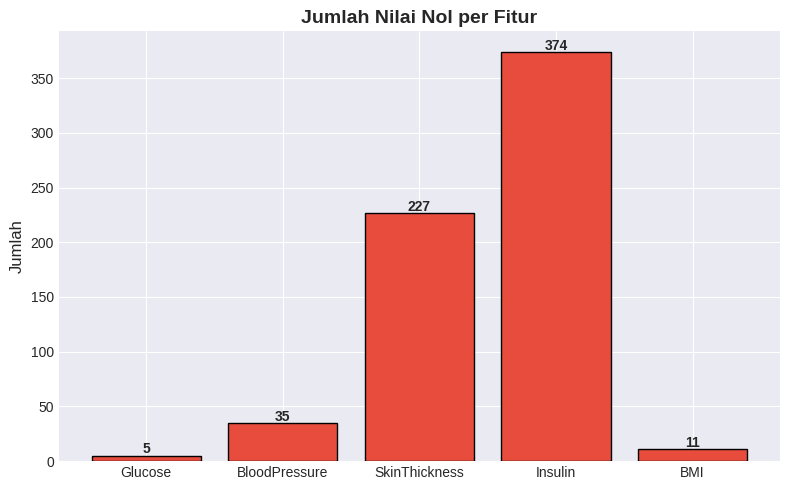

In [7]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = {col: (df[col] == 0).sum() for col in columns_with_zero}
zero_df = pd.DataFrame(list(zero_counts.items()), columns=['Fitur', 'Jumlah Nol'])
zero_df['Persentase'] = (zero_df['Jumlah Nol'] / len(df) * 100).round(2)
print(zero_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(zero_df['Fitur'], zero_df['Jumlah Nol'], color='#e74c3c', edgecolor='black')
ax.set_title('Jumlah Nilai Nol per Fitur', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah', fontsize=12)
for bar, val in zip(bars, zero_df['Jumlah Nol']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing/diabetes_preprocessing/zero_values.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.5 Analisis Korelasi

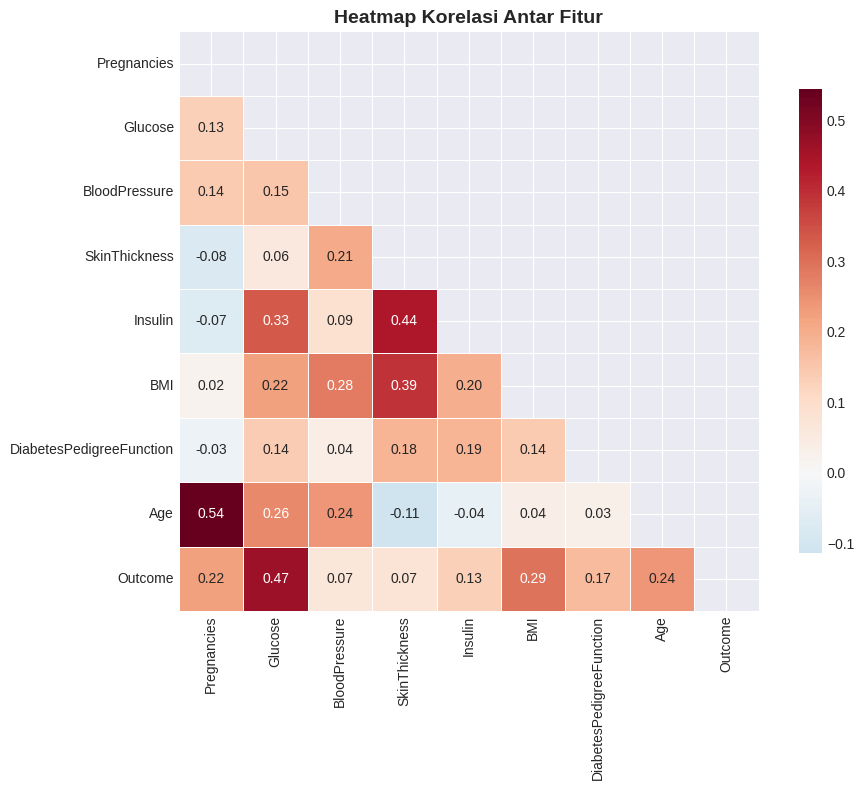

In [8]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing/diabetes_preprocessing/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.6 Distribusi Setiap Fitur

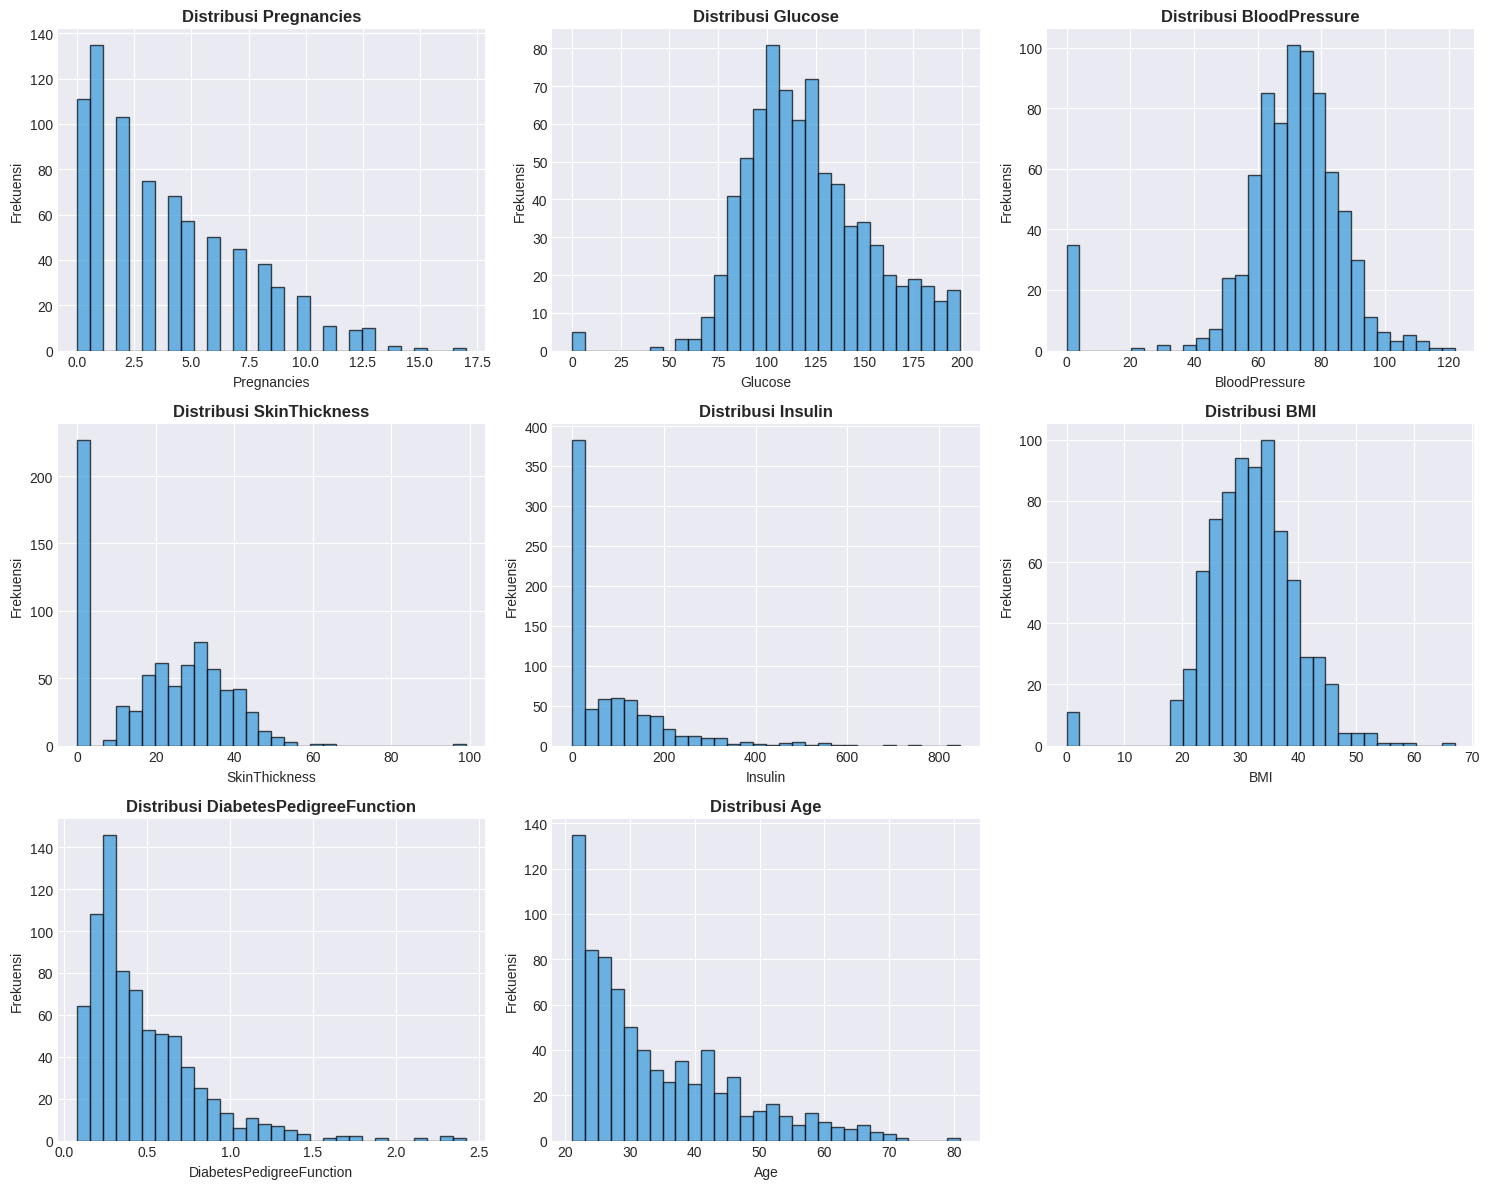

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
feature_cols = [c for c in df.columns if c != 'Outcome']
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('preprocessing/diabetes_preprocessing/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing

Preprocessing dilakukan untuk membersihkan dan mempersiapkan data sebelum digunakan dalam model machine learning.

### 5.1 Menangani Missing Values (Nilai Nol yang Tidak Valid)

In [10]:
df_clean = df.copy()
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_to_replace:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
print("[INFO] Nilai nol pada fitur medis telah diganti dengan median.")
print(f"\nCek nilai nol setelah preprocessing:")
print((df_clean[columns_to_replace] == 0).sum())

[INFO] Nilai nol pada fitur medis telah diganti dengan median.

Cek nilai nol setelah preprocessing:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


### 5.2 Feature Scaling (StandardScaler)

In [11]:
scaler = StandardScaler()
feature_cols = [c for c in df_clean.columns if c != 'Outcome']
df_scaled = df_clean.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
print("[INFO] StandardScaler telah diterapkan.")
print(f"\nStatistik setelah scaling:")
df_scaled[feature_cols].describe().T

[INFO] StandardScaler telah diterapkan.

Statistik setelah scaling:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,4.625929e-18,1.000652,-2.552931,-0.720163,-0.153073,0.611265,2.542658
BloodPressure,768.0,5.782412e-18,1.000652,-4.002619,-0.693761,-0.031990,0.629782,4.104082
SkinThickness,768.0,-1.526557e-16,1.000652,-2.516429,-0.467597,-0.012301,0.329171,7.955377
Insulin,768.0,1.503427e-17,1.000652,-1.467353,-0.222085,-0.181541,-0.155477,8.170442
BMI,768.0,2.613650e-16,1.000652,-2.074783,-0.721209,-0.022590,0.603256,5.042397
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


### 5.3 Split Data Train-Test

In [12]:
X = df_scaled[feature_cols]
y = df_scaled['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[INFO] Split data: Train={X_train.shape[0]}, Test={X_test.shape[0]}")
print(f"\nDistribusi target train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nDistribusi target test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

[INFO] Split data: Train=614, Test=154

Distribusi target train:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Distribusi target test:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


### 5.4 Menyimpan Hasil Preprocessing

In [13]:
output_dir = 'preprocessing/diabetes_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv(f'{output_dir}/train.csv', index=False)
test_df.to_csv(f'{output_dir}/test.csv', index=False)
df_clean.to_csv(f'{output_dir}/diabetes_clean.csv', index=False)
joblib.dump(scaler, f'{output_dir}/scaler.pkl')

print("[INFO] Hasil preprocessing disimpan:")
print(f"  - {output_dir}/train.csv")
print(f"  - {output_dir}/test.csv")
print(f"  - {output_dir}/diabetes_clean.csv")
print(f"  - {output_dir}/scaler.pkl")

[INFO] Hasil preprocessing disimpan:
  - preprocessing/diabetes_preprocessing/train.csv
  - preprocessing/diabetes_preprocessing/test.csv
  - preprocessing/diabetes_preprocessing/diabetes_clean.csv
  - preprocessing/diabetes_preprocessing/scaler.pkl


### 5.5 Summary

In [14]:
print("=" * 60)
print("EKSPERIMEN SELESAI")
print("=" * 60)
print(f"\nDataset: Pima Indians Diabetes")
print(f"Total sampel: {len(df)}")
print(f"Fitur: {len(feature_cols)}")
print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nFitur yang digunakan: {feature_cols}")
print(f"\nTarget encoding: 0 = Non-Diabetic, 1 = Diabetic")
print("\nDataset siap digunakan untuk pemodelan.")

EKSPERIMEN SELESAI

Dataset: Pima Indians Diabetes
Total sampel: 768
Fitur: 8
Train set: 614 samples
Test set: 154 samples

Fitur yang digunakan: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target encoding: 0 = Non-Diabetic, 1 = Diabetic

Dataset siap digunakan untuk pemodelan.
